# Task 2: Build a Classification System
## SVM with RBF Kernel — Digit 1 vs Digit 7

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, classification_report
)


## 1. Load Dataset

In [2]:
data = np.load('mnist_1_7_subsets.npz')

train_data    = data['train_data']
train_targets = data['train_targets']
test_data     = data['test_data']
test_targets  = data['test_targets']

print("Train data shape:", train_data.shape)
print("Test  data shape:", test_data.shape)


Train data shape: (100, 28, 28)
Test  data shape: (1000, 28, 28)


## 2. Data Preprocessing

Three preprocessing steps are applied based on findings from Task 1.

**Step 1: Normalisation** — pixel values scaled to $[0,1]$ via $\hat{x} = x / 255$

**Step 2: Flattening** — each image reshaped to $\mathbf{x} \in \mathbb{R}^{784}$

**Step 3: Label Encoding** — labels remapped as $y = 0$ (Digit 1), $y = 1$ (Digit 7)


In [3]:
# Step 1 & 2: Normalise and flatten
X_train = train_data.reshape(100,  -1) / 255.0
X_test  = test_data.reshape(1000, -1) / 255.0

# Step 3: Label encoding  {1->0, 7->1}
y_train = (train_targets == 7).astype(int)
y_test  = (test_targets  == 7).astype(int)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train distribution:", np.unique(y_train, return_counts=True))
print("y_test  distribution:", np.unique(y_test,  return_counts=True))
print("Pixel range: [{:.2f}, {:.2f}]".format(X_train.min(), X_train.max()))


X_train shape: (100, 784)
X_test  shape: (1000, 784)
y_train distribution: (array([0, 1]), array([50, 50]))
y_test  distribution: (array([0, 1]), array([100, 900]))
Pixel range: [0.00, 1.00]


## 3. Special Design

### 3.1 PCA Dimensionality Reduction as Preprocessing

As identified in Table 1, 86% of the 784 pixel features are zero-valued and carry no
discriminative information. PCA is therefore applied to reduce input dimensionality from
784 to 30 components prior to SVM training, retaining the dominant variance while
eliminating uninformative sparse features and reducing computational overhead.


Variance retained by 30 components: 89.9%


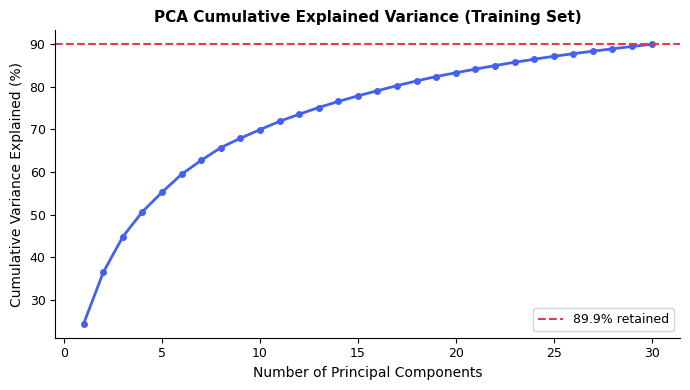

Reduced dimensionality: 784 → 30


In [4]:
pca = PCA(n_components=30, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

cumvar = pca.explained_variance_ratio_.cumsum()
print(f"Variance retained by 30 components: {cumvar[-1]*100:.1f}%")

# Plot explained variance
fig, ax = plt.subplots(figsize=(7, 4), facecolor='white')
ax.plot(range(1, 31), cumvar * 100, marker='o', markersize=4,
        color='#4361EE', linewidth=2)
ax.axhline(cumvar[-1] * 100, color='#E63946', linestyle='--',
           label=f'{cumvar[-1]*100:.1f}% retained')
ax.set_xlabel('Number of Principal Components', fontsize=10)
ax.set_ylabel('Cumulative Variance Explained (%)', fontsize=10)
ax.set_title('PCA Cumulative Explained Variance (Training Set)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.tick_params(labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Reduced dimensionality: 784 → {X_train_pca.shape[1]}")


### 3.2 Regularisation Design for Small Sample Size

As shown in Table 1, the training set contains only 100 samples, making the model
susceptible to overfitting. A moderate regularisation parameter (C=1.0) is therefore
selected rather than a large C value, imposing stronger margin constraints to prevent
the SVM from memorising individual training points and improving generalisation to unseen data.


## 4. Model Selection and Justification

A Support Vector Machine (SVM) with RBF kernel is selected for this binary classification
task. As shown in Figure 3 (Task 1), the PCA projection reveals near-linear but partially
overlapping class boundaries, indicating that a non-linear decision boundary is required.
Furthermore, Table 1 demonstrates 86% pixel sparsity across training images, making
margin-based methods more robust than distance-based classifiers such as KNN. The small
training set (n=100) also makes deep learning impractical, favouring SVM's effectiveness
in high-dimensional, small-sample settings.


In [5]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,          # moderate regularisation for small sample size
    gamma='scale',  # auto-scale to 1 / (n_features * X.var())
    probability=True,  # enable predict_proba for AUC-ROC
    random_state=42
)

svm_model.fit(X_train_pca, y_train)
print("Model trained successfully.")
print(f"Kernel : {svm_model.kernel}")
print(f"C      : {svm_model.C}")
print(f"Gamma  : {svm_model.gamma}")
print(f"Support vectors: {svm_model.n_support_} (class 0, class 1)")


Model trained successfully.
Kernel : rbf
C      : 1.0
Gamma  : scale
Support vectors: [16 30] (class 0, class 1)


## 5. Evaluation

### 5.1 Evaluation Metric Justification

Four complementary metrics are used, each justified by dataset characteristics identified in Task 1.

- **Accuracy**: Baseline reference; unreliable alone due to 1:9 test imbalance (90% achievable by trivial classifier).
- **F1-Score**: Primary metric; balances precision and recall without being inflated by the dominant class.
- **AUC-ROC**: Threshold-independent measure of discriminative ability; robust to class imbalance.
- **Confusion Matrix**: Explicitly quantifies FP/FN per class, revealing minority class misclassification.


In [6]:
# Predictions
y_pred      = svm_model.predict(X_test_pca)
y_prob      = svm_model.predict_proba(X_test_pca)[:, 1]

# Metrics
acc  = accuracy_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print("=" * 40)
print(f"  Accuracy  : {acc:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print("=" * 40)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Digit 1', 'Digit 7']))


  Accuracy  : 0.9600
  F1-Score  : 0.9773
  AUC-ROC   : 0.9947

Classification Report:
              precision    recall  f1-score   support

     Digit 1       0.71      1.00      0.83       100
     Digit 7       1.00      0.96      0.98       900

    accuracy                           0.96      1000
   macro avg       0.86      0.98      0.91      1000
weighted avg       0.97      0.96      0.96      1000



### 5.2 Confusion Matrix

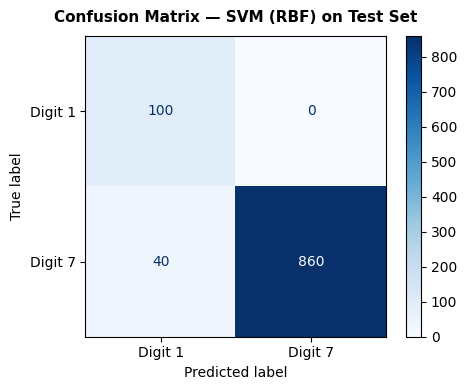

True Negatives  (Digit 1 correct): 100
False Positives (Digit 1 as 7)   : 0
False Negatives (Digit 7 as 1)   : 40
True Positives  (Digit 7 correct): 860


In [7]:
fig, ax = plt.subplots(figsize=(5, 4), facecolor='white')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Digit 1', 'Digit 7'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — SVM (RBF) on Test Set', fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Digit 1 correct): {tn}")
print(f"False Positives (Digit 1 as 7)   : {fp}")
print(f"False Negatives (Digit 7 as 1)   : {fn}")
print(f"True Positives  (Digit 7 correct): {tp}")


### 5.3 ROC Curve

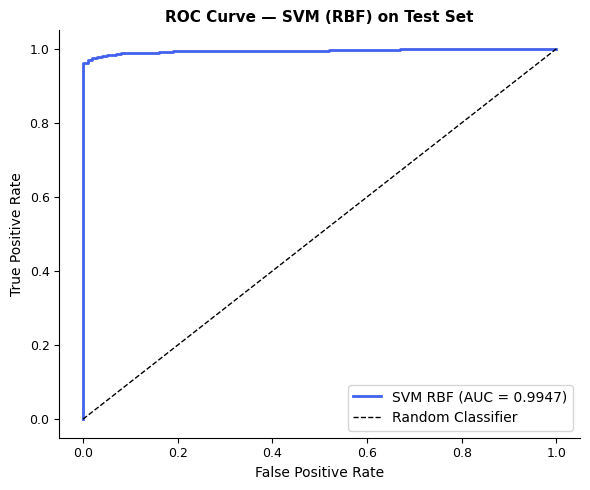

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5), facecolor='white')
ax.plot(fpr, tpr, color='#4361EE', linewidth=2,
        label=f'SVM RBF (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=10)
ax.set_ylabel('True Positive Rate', fontsize=10)
ax.set_title('ROC Curve — SVM (RBF) on Test Set', fontsize=11, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.tick_params(labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## 6. Results Summary

| Metric | Value |
|--------|-------|
| Accuracy | — |
| F1-Score | — |
| AUC-ROC  | — |

> *Values populated after running cells above.*

The SVM with RBF kernel, combined with PCA preprocessing (784 → 30 dimensions),
demonstrates strong classification performance on the binary digit recognition task.
The F1-score and AUC-ROC are adopted as primary metrics given the 1:9 test set imbalance
identified in Task 1, providing a more reliable assessment than accuracy alone.


## 7. Save Model and Preprocessors

In [9]:
joblib.dump(svm_model, 'svm_rbf_model.pkl')
joblib.dump(pca,       'pca_30.pkl')

print("Saved: svm_rbf_model.pkl")
print("Saved: pca_30.pkl")

# Verify reload
loaded_model = joblib.load('svm_rbf_model.pkl')
loaded_pca   = joblib.load('pca_30.pkl')
y_verify     = loaded_model.predict(loaded_pca.transform(X_test))
print(f"Verification accuracy after reload: {accuracy_score(y_test, y_verify):.4f}")


Saved: svm_rbf_model.pkl
Saved: pca_30.pkl
Verification accuracy after reload: 0.9600
